In [68]:
import os, sys, json, csv
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from collections import Counter

PROJECT_ROOT = os.path.abspath("..")
sys.path.insert(0, PROJECT_ROOT)
sys.path.append(os.path.join(PROJECT_ROOT, "cs195-ska-projects/shared/ska_agent-1.0.0-8"))

from ska_agent.core.pricing import PricingEngine
from ska_agent.models.embedding import Embedder
from shared.constants import LAMBDA_GRID, ETA_REDUNDANCY, MAX_SEGMENTS, MODES, EPS
from shared.corpus import make_officeqa_synthetic_corpus, build_segments_from_texts
from shared.scoring import complexity_aligned_lambda_score, get_selected_indices, ensure_1d
from shared.io_utils import load_records, load_held_out_qids

W6 = os.path.join(PROJECT_ROOT, "outputs", "week6")
OUT = os.path.join(PROJECT_ROOT, "outputs", "week7")
os.makedirs(OUT, exist_ok=True)
print(f"W6: {W6}")
print(f"OUT: {OUT}")

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

W6: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week6
OUT: /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week7


In [69]:
segment_texts, questions, relevant_by_qid, _ = make_officeqa_synthetic_corpus(
    n_per_mode=25, n_paraphrases=7, seed=SEED,
)
embedder = Embedder(model_name="all-MiniLM-L6-v2")
segments = build_segments_from_texts(segment_texts, embedder)

held_out_qids = load_held_out_qids(f"{W6}/held_out_qids.json")
test_questions = [q for q in questions if q.question_id in held_out_qids]
train_records = load_records(f"{W6}/train_sweep_records.json")
test_records = load_records(f"{W6}/test_sweep_records.json")

print(f"Test queries: {len(test_questions)}")
print(f"Test mode counts: {Counter(q.question_type for q in test_questions)}")

No GPU found. Using lightweight CPU embedder: Alibaba-NLP/gte-Qwen2-1.5B-instruct
Loading embedding model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

/Users/kevincapcha/PycharmProjects/CS195S2026/cs195-ska-projects/shared/ska_agent-1.0.0-8/ska_agent/models/embedding.py:51: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  self.embedding_dim = self.model.get_sentence_embedding_dimension()


Embedder ready (dim=384)
Test queries: 140
Test mode counts: Counter({'LOOKUP': 35, 'MULTI_DOC': 35, 'COMPUTE': 35, 'MULTI_STEP': 35})


In [70]:
class LambdaPredictor(nn.Module):
    """Same architecture as Week 6 — log-MSE regressor."""
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

ckpt = torch.load(f"{W6}/lambda_predictor_week6_checkpoint.pt", weights_only=False)
model = LambdaPredictor(input_dim=ckpt["input_dim"], hidden_dim=ckpt["hidden_dim"])
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded Week 6 model. Val log-MSE was {ckpt['val_mse']:.4f}")

def learned_lambda_for_query(query_text):
    """Predict lambda from query embedding via the regressor."""
    emb = ensure_1d(embedder.embed_single(query_text)).astype(np.float32)
    with torch.no_grad():
        log_lam = model(torch.tensor(emb).unsqueeze(0)).item()
    return float(np.exp(log_lam))

Loaded Week 6 model. Val log-MSE was 1.1512


In [71]:
# Strategy 1: fixed_default
LAM_DEFAULT = 0.05

# Strategy 2: fixed_best — single lambda that maximizes mean training-set score
mean_score_by_lambda = {
    lam: np.mean([r["final_lambda_score"] for r in train_records if r["lambda"] == lam])
    for lam in LAMBDA_GRID
}
LAM_BEST = max(mean_score_by_lambda, key=mean_score_by_lambda.get)
print(f"Best fixed lambda from training: {LAM_BEST}")
print(f"Per-lambda mean training scores: {mean_score_by_lambda}")

# Strategy 3: learned — per-query MLP prediction (defined in Cell 3)
# Strategy 4: oracle — per-query best from test sweep
oracle_lambda = {r["question_id"]: r["lambda"] for r in test_records if r["is_optimal"]}

Best fixed lambda from training: 0.1
Per-lambda mean training scores: {0.001: np.float64(0.04804166666666661), 0.005: np.float64(0.06018452380952377), 0.01: np.float64(0.09186309523809516), 0.02: np.float64(0.15225595238095235), 0.05: np.float64(0.2295416666666667), 0.1: np.float64(0.2345178571428571), 0.2: np.float64(0.23354761904761898), 0.5: np.float64(-0.021696428571428582)}


In [72]:
def run_one(query_text, mode, qid, relevant_idx, lam_value):
    engine = PricingEngine(
        segments=segments, embed_fn=embedder.embed_single,
        lambda_sparsity=lam_value, eta_redundancy=ETA_REDUNDANCY,
        max_segments=MAX_SEGMENTS,
    )
    result = engine.retrieve(query_text, verbose=False)
    selected = get_selected_indices(result)
    score, metrics = complexity_aligned_lambda_score(selected, relevant_idx, mode)
    total_rc = (float(np.sum(result.reduced_costs))
                if result.reduced_costs is not None and len(result.reduced_costs) > 0 else 0.0)
    return {
        "qid": qid, "mode": mode, "lambda": lam_value,
        "num_segments": len(result.segments),
        "total_reduced_cost": total_rc,
        "selected_texts": [s.text for s in result.segments],
        **metrics, "score": score,
    }

results_by_config = {
    "fixed_default": [], "fixed_best": [], "learned": [], "oracle": [],
}

for q in test_questions:
    rel = relevant_by_qid[q.question_id]
    results_by_config["fixed_default"].append(
        run_one(q.question, q.question_type, q.question_id, rel, LAM_DEFAULT))
    results_by_config["fixed_best"].append(
        run_one(q.question, q.question_type, q.question_id, rel, LAM_BEST))
    results_by_config["learned"].append(
        run_one(q.question, q.question_type, q.question_id, rel,
                learned_lambda_for_query(q.question)))
    results_by_config["oracle"].append(
        run_one(q.question, q.question_type, q.question_id, rel,
                oracle_lambda[q.question_id]))

with open(f"{OUT}/comparison_results_seed0.json", "w") as f:
    json.dump(results_by_config, f, indent=2)
print(f"Ran {len(test_questions)} test queries through 4 configs.")

Ran 140 test queries through 4 configs.


In [73]:
print(f"\n{'Config':<16} {'AvgCov':>8} {'AvgPrec':>9} {'AvgF1':>8} {'AvgSegs':>9} {'AvgRC':>10}")
print("-" * 72)
for cfg, rs in results_by_config.items():
    print(f"{cfg:<16} "
          f"{np.mean([r['evidence_coverage'] for r in rs]):>8.3f} "
          f"{np.mean([r['precision'] for r in rs]):>9.3f} "
          f"{np.mean([r['f1'] for r in rs]):>8.3f} "
          f"{np.mean([r['num_segments'] for r in rs]):>9.2f} "
          f"{np.mean([r['total_reduced_cost'] for r in rs]):>10.3f}")

print("\nBy mode (coverage):")
print(f"{'Mode':<12} " + " ".join(f"{cfg:>14}" for cfg in results_by_config))
for mode in MODES:
    row = f"{mode:<12} "
    for cfg, rs in results_by_config.items():
        rs_mode = [r for r in rs if r["mode"] == mode]
        cov = np.mean([r["evidence_coverage"] for r in rs_mode])
        row += f"{cov:>14.3f} "
    print(row)


Config             AvgCov   AvgPrec    AvgF1   AvgSegs      AvgRC
------------------------------------------------------------------------
fixed_default       0.474     0.742    0.552      1.16     -0.494
fixed_best          0.474     0.779    0.562      1.00     -0.442
learned             0.461     0.750    0.544      0.97     -0.240
oracle              0.568     0.778    0.606      1.71     -0.244

By mode (coverage):
Mode          fixed_default     fixed_best        learned         oracle
LOOKUP                1.000          1.000          1.000          1.000 
MULTI_DOC             0.300          0.300          0.257          0.471 
COMPUTE               0.271          0.271          0.271          0.400 
MULTI_STEP            0.324          0.324          0.314          0.400 


In [74]:
def build_training_dataset(records, embed_fn):
    from shared.scoring import ensure_1d
    optimal = [r for r in records if r["is_optimal"]]
    queries = [r["query"] for r in optimal]
    modes = [r["mode"] for r in optimal]
    y = np.asarray([r["lambda"] for r in optimal], dtype=np.float32)
    embeddings = [ensure_1d(embed_fn(q)) for q in queries]
    X = np.asarray(embeddings, dtype=np.float32)
    return X, y, queries, modes

def retrain_mlp(seed):
    from shared.predictor import stratified_train_val_split
    X, y, _, optimal_modes_local = build_training_dataset(train_records, embedder.embed_single)

    # ===== DEBUG: Check training targets =====
    print(f"y values (lambdas to predict): min={np.min(y):.4f}, max={np.max(y):.4f}, mean={np.mean(y):.4f}")
    print(f"First 10 y values: {y[:10]}")
    print(f"Log-space y values: min={np.min(np.log(np.clip(y, 1e-6, None))):.4f}, max={np.max(np.log(np.clip(y, 1e-6, None))):.4f}")
    # ========================================

    X_tr, X_va, y_tr, y_va, _, _ = stratified_train_val_split(
        X, y, optimal_modes_local, val_frac=0.2, seed=seed,
    )
    torch.manual_seed(seed)
    np.random.seed(seed)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(np.log(np.clip(y_tr, EPS, None)), dtype=torch.float32)
    m = LambdaPredictor(input_dim=X_tr.shape[1], hidden_dim=64)
    opt = optim.Adam(m.parameters(), lr=1e-3)
    crit = nn.MSELoss()
    for _ in range(200):
        m.train(); opt.zero_grad()
        loss = crit(m(X_tr_t), y_tr_t)
        loss.backward()
        opt.step()
    # ===== DEBUG: Check final loss =====
    m.eval()
    final_loss = crit(m(X_tr_t), y_tr_t).item()
    print(f"Final training loss: {final_loss:.6f}")
    # ===================================
    return m

def predict_lambda_with(m, query_text):
    emb = ensure_1d(embedder.embed_single(query_text)).astype(np.float32)
    with torch.no_grad():
        return float(np.exp(m(torch.tensor(emb).unsqueeze(0)).item()))

seeds = [0, 1, 2]
multi_seed_results = {cfg: [] for cfg in results_by_config}

for seed in seeds:
    print(f"\nSeed {seed}: retraining MLP...")
    m_seed = retrain_mlp(seed)

    # ===== DEBUG OUTPUT HERE =====
    test_lambdas = [predict_lambda_with(m_seed, test_questions[i].question)
                    for i in range(min(3, len(test_questions)))]
    print(f"First 3 predicted lambdas: {test_lambdas}")
    # =============================

    learned_seed = []
    for q in test_questions:
        learned_seed.append(run_one(
            q.question, q.question_type, q.question_id,
            relevant_by_qid[q.question_id],
            predict_lambda_with(m_seed, q.question),
        ))

    # ===== DEBUG OUTPUT HERE =====
    print(f"Seed {seed} learned results count: {len(learned_seed)}, "
          f"avg coverage: {np.mean([r['evidence_coverage'] for r in learned_seed])}")
    # =============================

    multi_seed_results["learned"].append(learned_seed)
    multi_seed_results["fixed_default"].append(results_by_config["fixed_default"])
    multi_seed_results["fixed_best"].append(results_by_config["fixed_best"])
    multi_seed_results["oracle"].append(results_by_config["oracle"])

print("\n\nMulti-seed comparison (mean ± std across 3 seeds):")
print(f"{'Config':<16} {'AvgCov':>16} {'AvgSegs':>16}")
print("-" * 52)
for cfg in results_by_config:
    covs = [np.mean([r["evidence_coverage"] for r in rs])
            for rs in multi_seed_results[cfg]]
    segs = [np.mean([r["num_segments"] for r in rs])
            for rs in multi_seed_results[cfg]]
    print(f"{cfg:<16} {np.mean(covs):>8.3f} ± {np.std(covs):>5.3f} "
          f"{np.mean(segs):>8.2f} ± {np.std(segs):>5.2f}")


Seed 0: retraining MLP...
y values (lambdas to predict): min=0.0050, max=0.5000, mean=0.3365
First 10 y values: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Log-space y values: min=-5.2983, max=-0.6931
Final training loss: 0.596313
First 3 predicted lambdas: [0.18422613842405877, 0.31366805139423715, 0.15938952908016477]
Seed 0 learned results count: 140, avg coverage: 0.45833333333333326

Seed 1: retraining MLP...
y values (lambdas to predict): min=0.0050, max=0.5000, mean=0.3365
First 10 y values: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Log-space y values: min=-5.2983, max=-0.6931
Final training loss: 0.704806
First 3 predicted lambdas: [0.17479426385216984, 0.26286902196031997, 0.16195581800848907]
Seed 1 learned results count: 140, avg coverage: 0.46309523809523806

Seed 2: retraining MLP...
y values (lambdas to predict): min=0.0050, max=0.5000, mean=0.3365
First 10 y values: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]
Log-space y values: min=-5.2983, max=-0.6931
Final training loss:

In [75]:
rng = np.random.default_rng(SEED)
sample_qids = rng.choice(
    [q.question_id for q in test_questions],
    size=min(20, len(test_questions)), replace=False,
)

with open(f"{OUT}/spot_check.csv", "w", newline="") as f:
    w = csv.writer(f)
    w.writerow(["qid", "mode", "config", "lambda", "num_segments",
                "coverage", "precision", "selected_texts", "gold_answer"])
    for qid in sample_qids:
        q = next(qq for qq in test_questions if qq.question_id == qid)
        for cfg, rs in results_by_config.items():
            r = next(rr for rr in rs if rr["qid"] == qid)
            w.writerow([qid, q.question_type, cfg, r["lambda"], r["num_segments"],
                        r["evidence_coverage"], r["precision"],
                        " ||| ".join(r["selected_texts"]), q.answer])
print(f"Saved spot-check CSV to {OUT}/spot_check.csv — open in a spreadsheet to review.")

Saved spot-check CSV to /Users/kevincapcha/PycharmProjects/CS195S2026/outputs/week7/spot_check.csv — open in a spreadsheet to review.


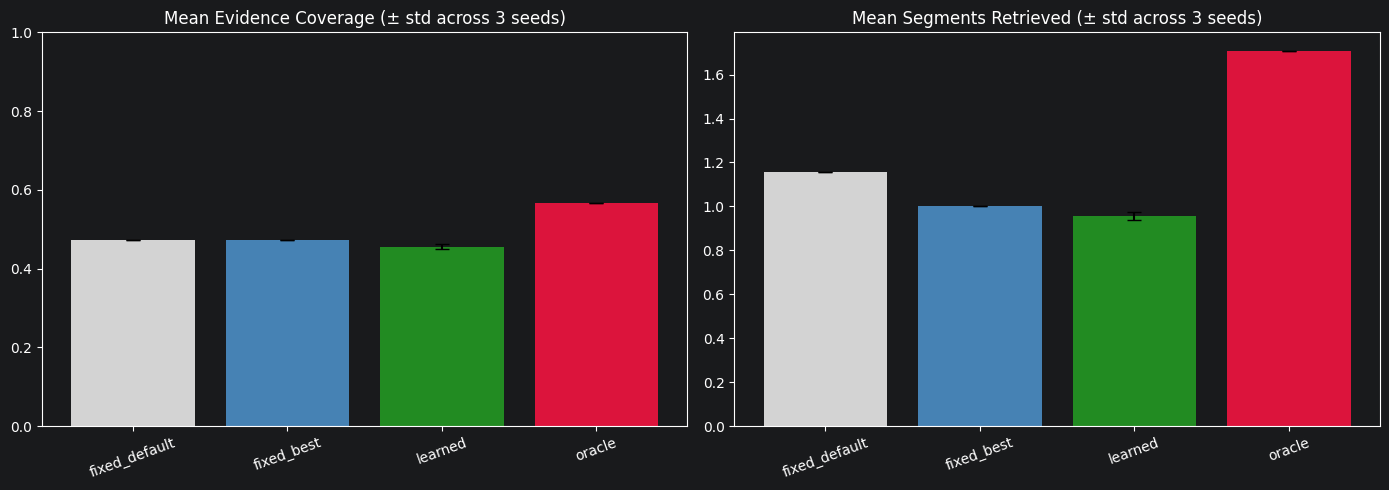

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
configs = list(results_by_config.keys())
colors = ["lightgray", "steelblue", "forestgreen", "crimson"]

cov_means, cov_stds, seg_means, seg_stds = [], [], [], []
for cfg in configs:
    covs = [np.mean([r["evidence_coverage"] for r in rs])
            for rs in multi_seed_results[cfg]]
    segs = [np.mean([r["num_segments"] for r in rs])
            for rs in multi_seed_results[cfg]]
    cov_means.append(np.mean(covs)); cov_stds.append(np.std(covs))
    seg_means.append(np.mean(segs)); seg_stds.append(np.std(segs))

axes[0].bar(configs, cov_means, yerr=cov_stds, color=colors, capsize=5)
axes[0].set_title("Mean Evidence Coverage (± std across 3 seeds)")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(configs, seg_means, yerr=seg_stds, color=colors, capsize=5)
axes[1].set_title("Mean Segments Retrieved (± std across 3 seeds)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(f"{OUT}/comparison_bar.png", dpi=150)
plt.show()